# Treinamento e Avaliação com XGBoost
Este notebook treina um modelo XGBoost para prever `preco_medio_ton_usd` e avalia o desempenho usando MSE, RMSE e R².

    tipo_carne   ano  trimestre  producao_cabecas_anual_mi  abate_cabecas  \
0       bovino  2015          1                     215.20          7.737   
1       bovino  2015          2                     215.20          7.626   
2       bovino  2015          3                     215.20          7.578   
3       bovino  2015          4                     215.20          7.693   
4       bovino  2016          1                     218.23          7.303   
..         ...   ...        ...                        ...            ...   
115      suino  2023          4                      43.00         14.148   
116      suino  2024          1                      43.90         14.019   
117      suino  2024          2                      43.90         14.567   
118      suino  2024          3                      43.90         14.956   
119      suino  2024          4                      43.90         14.275   

     peso_carcaca_ton  exportacao_usd  media_cambio_usdbrl  custo_milho_rs 

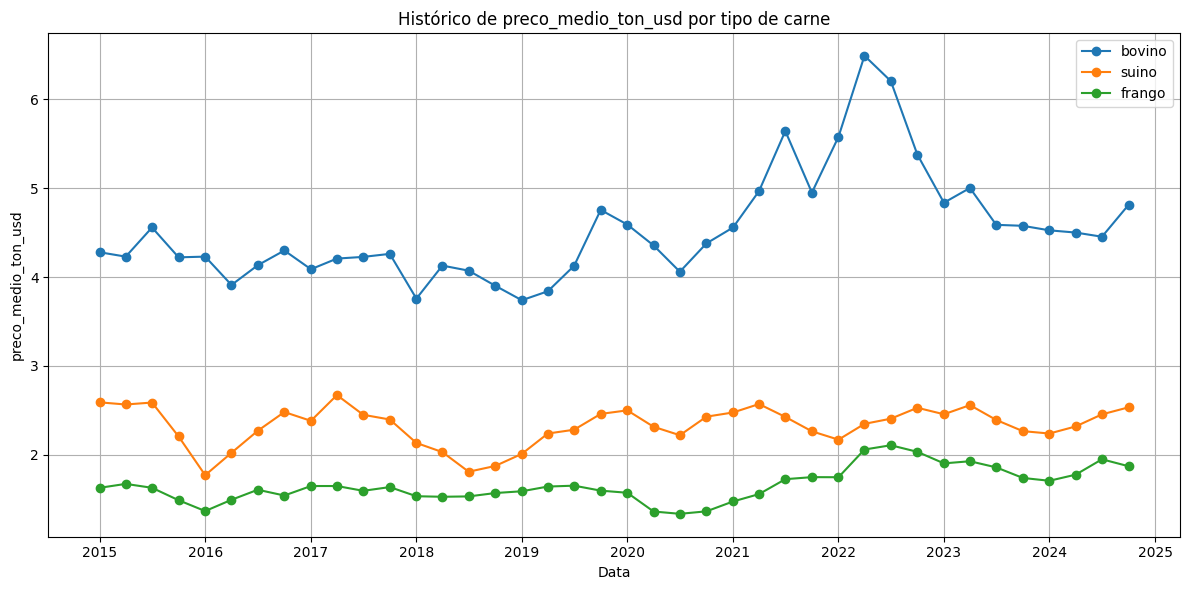


=== Tipo de carne: bovino ===
Fitting 2 folds for each of 432 candidates, totalling 864 fits
Melhores hiperparâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 1.0}
Melhor CV (neg MSE): -0.4930
CV média (treino): MSE=0.4930, RMSE=0.7021, R²=-0.4402
Test MSE: 0.0255
Test RMSE: 0.1598
Test R²: 0.2434


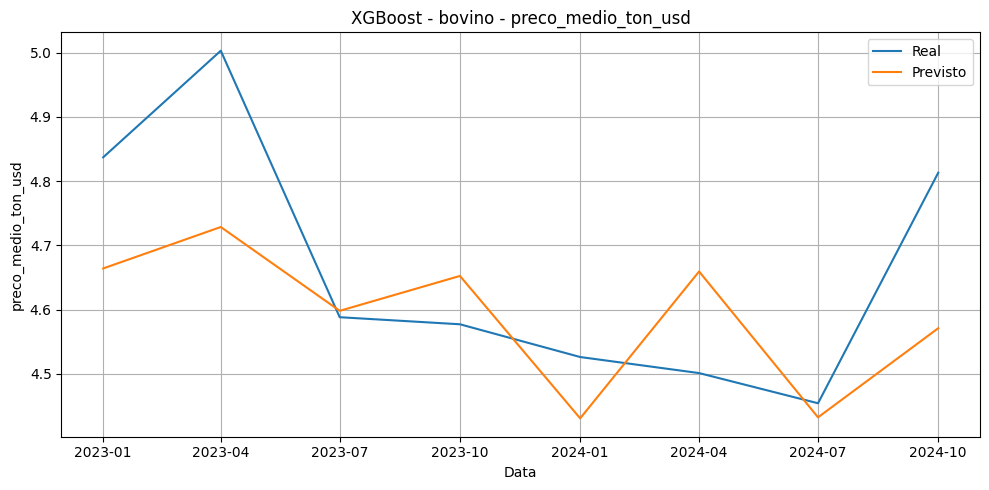


=== Tipo de carne: suino ===
Fitting 2 folds for each of 432 candidates, totalling 864 fits
Melhores hiperparâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0}
Melhor CV (neg MSE): -0.0261
CV média (treino): MSE=0.0261, RMSE=0.1616, R²=0.1759
Test MSE: 0.0020
Test RMSE: 0.0446
Test R²: 0.8405


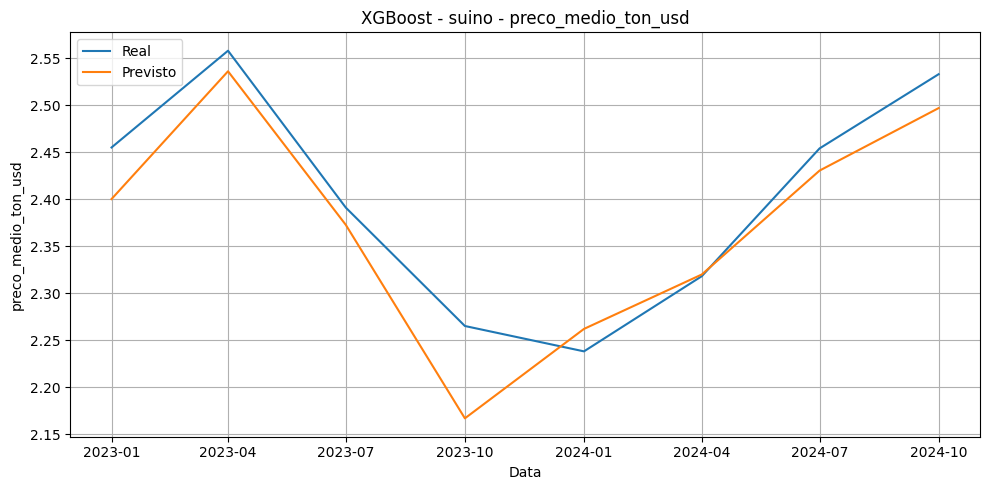


=== Tipo de carne: frango ===
Fitting 2 folds for each of 432 candidates, totalling 864 fits
Melhores hiperparâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.8}
Melhor CV (neg MSE): -0.0385
CV média (treino): MSE=0.0385, RMSE=0.1962, R²=0.1489
Test MSE: 0.0279
Test RMSE: 0.1670
Test R²: -2.9361


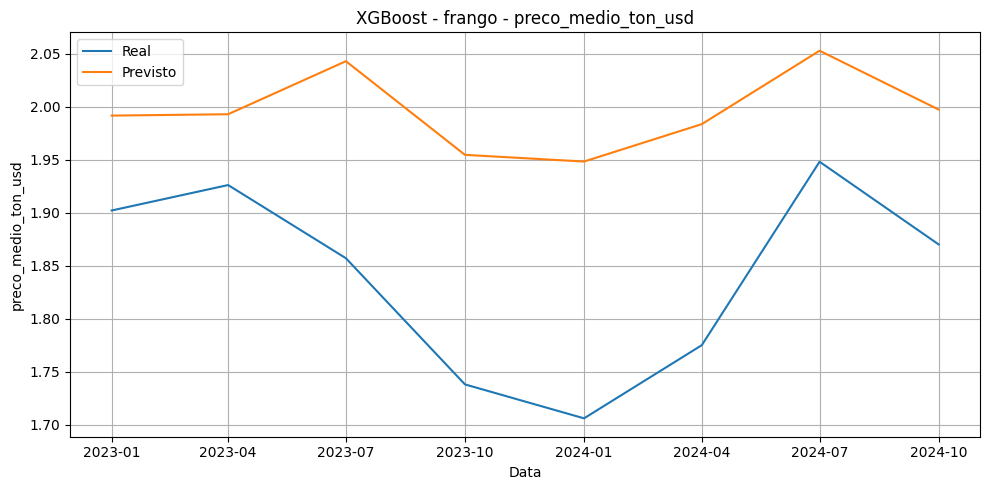


=== Resumo final ===
bovino: train=32, test=8, CV MSE=0.4930, CV RMSE=0.7021, CV R²=-0.4402, Test MSE=0.0255, Test RMSE=0.1598, Test R²=0.2434
suino: train=32, test=8, CV MSE=0.0261, CV RMSE=0.1616, CV R²=0.1759, Test MSE=0.0020, Test RMSE=0.0446, Test R²=0.8405
frango: train=32, test=8, CV MSE=0.0385, CV RMSE=0.1962, CV R²=0.1489, Test MSE=0.0279, Test RMSE=0.1670, Test R²=-2.9361


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score

# Carregar dados
df = pd.read_csv("/content/carne-brasileira-derivada.csv")
df["date"] = pd.to_datetime(
    df["ano"].astype(str)
    + "-"
    + ((df["trimestre"] - 1) * 3 + 1).astype(str).str.zfill(2)
    + "-01"
)
df = df.sort_values(["tipo_carne", "date"]).reset_index(drop=True)
print(df)

# Configurar target e tipos de carne
target_column = "preco_medio_ton_usd"
meat_types = ["bovino", "suino", "frango"]

# Visualizar histórico do alvo por tipo de carne
plt.figure(figsize=(12, 6))
for meat_type in meat_types:
    df_meat = df[df["tipo_carne"] == meat_type]
    plt.plot(df_meat["date"], df_meat[target_column], marker="o", label=meat_type)
plt.title(f"Histórico de {target_column} por tipo de carne")
plt.xlabel("Data")
plt.ylabel(target_column)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

feature_columns = [
    "producao_cabecas_anual_mi",
    "abate_cabecas",
    "peso_carcaca_ton",
    "media_cambio_usdbrl",
    "custo_milho_rs",
    "custo_soja_rs",
    "time_index",
    "quarter_sin",
    "quarter_cos",
    "halfyear_sin",
    "halfyear_cos",
    "exportacao_usd_lag1",
    "exportacao_usd_lag2",
    "exportacao_usd_lag3",
    "exportacao_usd_lag4",
    "exportacao_usd_rolling_mean_4",
    "exportacao_usd_ewm_4",
    "exportacao_usd_diff_1",
    "exportacao_usd_pct_change_a",
    "preco_medio_ton_usd_lag1",
    "preco_medio_ton_usd_lag2",
    "preco_medio_ton_usd_lag3",
    "preco_medio_ton_usd_lag4",
    "preco_medio_ton_usd_rolling_mean_4",
    "preco_medio_ton_usd_ewm_4",
    "preco_medio_ton_usd_diff_1",
    "preco_medio_ton_usd_pct_change_a",
]

all_results = []
for meat_type in meat_types:
    print(f"\n=== Tipo de carne: {meat_type} ===")
    df_filtered = df[df["tipo_carne"] == meat_type].copy()
    df_filtered = df_filtered.sort_values("date").reset_index(drop=True)

    df_model = df_filtered.dropna(subset=feature_columns + [target_column]).reset_index(drop=True)
    train_size = int(len(df_model) * 0.8)
    train = df_model.iloc[:train_size]
    test = df_model.iloc[train_size:]

    X_train = train[feature_columns]
    y_train = train[target_column]
    X_test = test[feature_columns]
    y_test = test[target_column]

    tscv = TimeSeriesSplit(n_splits=2)
    param_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "reg_lambda": [0.0, 1.0],
        "reg_alpha": [0.0, 0.5],
    }
    base_model = XGBRegressor(objective="reg:squarederror", random_state=42)
    grid_search = GridSearchCV(
        base_model,
        param_grid,
        cv=tscv,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
    )
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    cv_mse = -grid_search.best_score_
    cv_rmse = np.sqrt(cv_mse)
    cv_r2_scores = cross_val_score(best_model, X_train, y_train, cv=tscv, scoring="r2", n_jobs=-1)
    cv_r2 = np.mean(cv_r2_scores)
    print("Melhores hiperparâmetros:", grid_search.best_params_)
    print(f"Melhor CV (neg MSE): {grid_search.best_score_:.4f}")
    print(f"CV média (treino): MSE={cv_mse:.4f}, RMSE={cv_rmse:.4f}, R²={cv_r2:.4f}")

    predictions = best_model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f"Test MSE: {mse:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test R²: {r2:.4f}")

    all_results.append({
        "meat_type": meat_type,
        "cv_mse": cv_mse,
        "cv_rmse": cv_rmse,
        "cv_r2": cv_r2,
        "test_mse": mse,
        "test_rmse": rmse,
        "test_r2": r2,
        "train_size": len(X_train),
        "test_size": len(X_test),
    })

    plt.figure(figsize=(10, 5))
    plt.plot(test["date"].reset_index(drop=True), y_test.values, label="Real")
    plt.plot(test["date"].reset_index(drop=True), predictions, label="Previsto")
    plt.title(f"XGBoost - {meat_type} - {target_column}")
    plt.xlabel("Data")
    plt.ylabel(target_column)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n=== Resumo final ===")
for res in all_results:
    print(
        f"{res['meat_type']}: train={res['train_size']}, test={res['test_size']}, "
        f"CV MSE={res['cv_mse']:.4f}, CV RMSE={res['cv_rmse']:.4f}, CV R²={res['cv_r2']:.4f}, "
        f"Test MSE={res['test_mse']:.4f}, Test RMSE={res['test_rmse']:.4f}, Test R²={res['test_r2']:.4f}"
    )
